In [6]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
import json
vector.register_awkward()





wr20_n19 = "/gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNEltoElElJJ_MWR2000_N1900_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/120000/8671fc68-7035-485a-935c-21955b49f582.root"
wr40_n39 = "/gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNEltoElElJJ_MWR4000_N3900_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/130000/3045224b-9de4-4e2f-aa22-b670feaccd66.root"
wr60_n59 = "/gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNEltoElElJJ_MWR6000_N5900_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/130000/f3687341-4e56-4872-a512-d338e9548441.root"

file1 = uproot.open(wr20_n19)
file2 = uproot.open(wr40_n39)
file3 = uproot.open(wr60_n59)


## WR2000 N 1900 

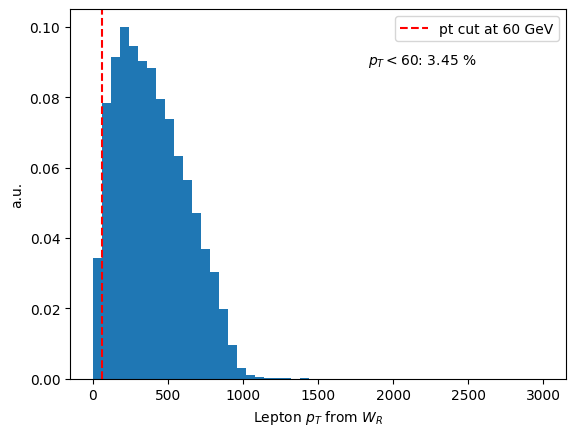

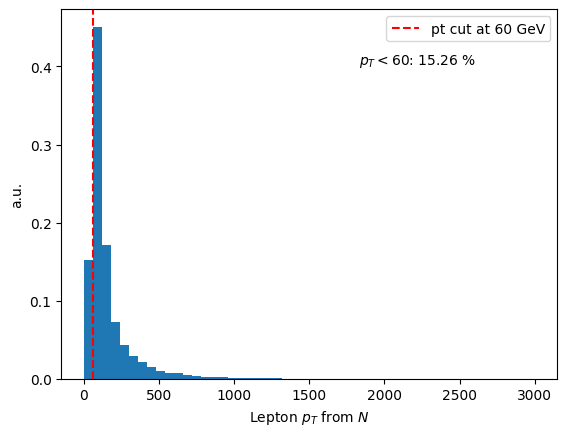

In [15]:
events = file1["Events"]
lhe_pt = events["LHEPart_pt"].array()

wr_np = lhe_pt[:, 2]
n_np  = lhe_pt[:, -1]

# numpy로 변환 (hist/weights 안정성)
wr_vals = ak.to_numpy(wr_np)
n_vals  = ak.to_numpy(n_np)

# 정규화 가중치 (a.u.)
w_wr = np.ones(len(wr_vals)) / len(wr_vals)
w_n  = np.ones(len(n_vals)) / len(n_vals)

# pt < 60 GeV 이벤트 비율 (%)
wr_lt60 = np.sum(wr_vals < 60) / len(wr_vals) * 100
n_lt60  = np.sum(n_vals < 60) / len(n_vals) * 100

plt.hist(wr_vals, bins=50, range=(0, 3000), weights=w_wr)
plt.xlabel("Lepton $p_{T}$ from $W_{R}$")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')
plt.text(0.60, 0.85, f"$p_{{T}} < 60$: {wr_lt60:.2f} %", transform=plt.gca().transAxes)
plt.legend()
plt.savefig("WR2000N1900_lepton_pt_from_WR.png")  # ✅ 그래프 저장
plt.show()

plt.hist(n_vals, bins=50, range=(0, 3000), weights=w_n)
plt.xlabel("Lepton $p_{T}$ from $N$")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')
plt.text(0.60, 0.85, f"$p_{{T}} < 60$: {n_lt60:.2f} %", transform=plt.gca().transAxes)
plt.legend()
plt.savefig("WR2000N1900_lepton_pt_from_N.png")  # ✅ 그래프 저장
plt.show()


## WR 4000 N 3900

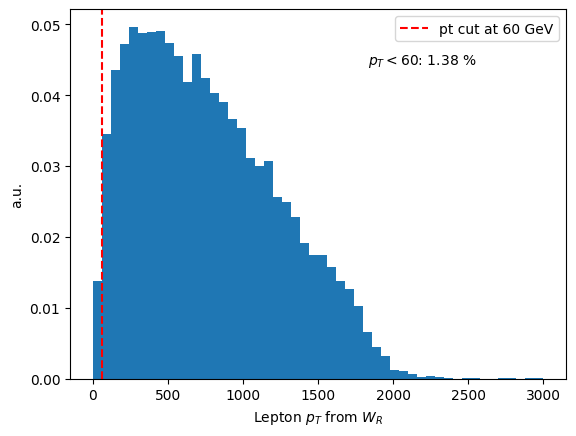

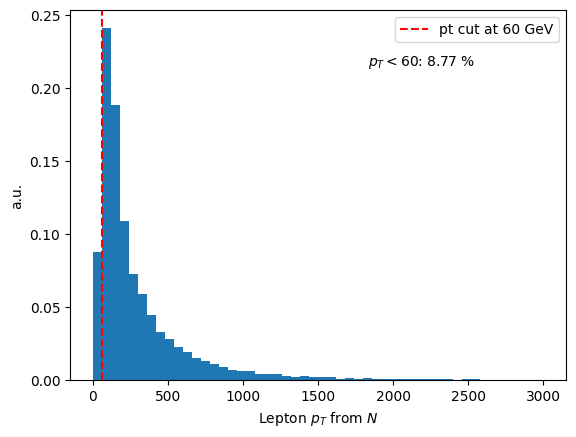

In [16]:
events = file2["Events"]
lhe_pt = events["LHEPart_pt"].array()

wr_np = lhe_pt[:, 2]
n_np  = lhe_pt[:, -1]

# numpy로 변환 (hist/weights 안정성)
wr_vals = ak.to_numpy(wr_np)
n_vals  = ak.to_numpy(n_np)

# 정규화 가중치 (a.u.)
w_wr = np.ones(len(wr_vals)) / len(wr_vals)
w_n  = np.ones(len(n_vals)) / len(n_vals)

# pt < 60 GeV 이벤트 비율 (%)
wr_lt60 = np.sum(wr_vals < 60) / len(wr_vals) * 100
n_lt60  = np.sum(n_vals < 60) / len(n_vals) * 100

plt.hist(wr_vals, bins=50, range=(0, 3000), weights=w_wr)
plt.xlabel("Lepton $p_{T}$ from $W_{R}$")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')
plt.text(0.60, 0.85, f"$p_{{T}} < 60$: {wr_lt60:.2f} %", transform=plt.gca().transAxes)
plt.legend()
plt.savefig("WR4000N3900_lepton_pt_from_WR.png")  # ✅ 그래프 저장
plt.show()

plt.hist(n_vals, bins=50, range=(0, 3000), weights=w_n)
plt.xlabel("Lepton $p_{T}$ from $N$")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')
plt.text(0.60, 0.85, f"$p_{{T}} < 60$: {n_lt60:.2f} %", transform=plt.gca().transAxes)
plt.legend()
plt.savefig("WR4000N3900_lepton_pt_from_N.png")  # ✅ 그래프 저장
plt.show()


## WR 6000 N 5900

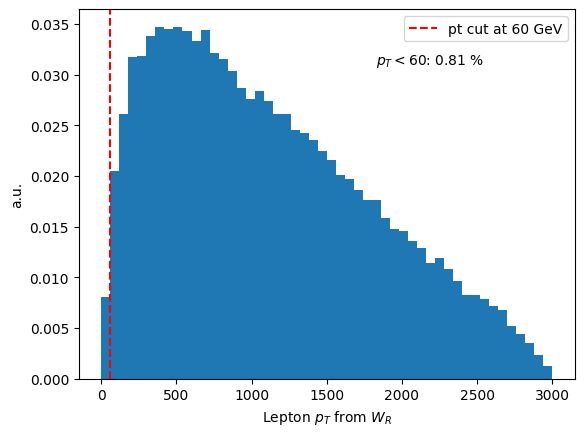

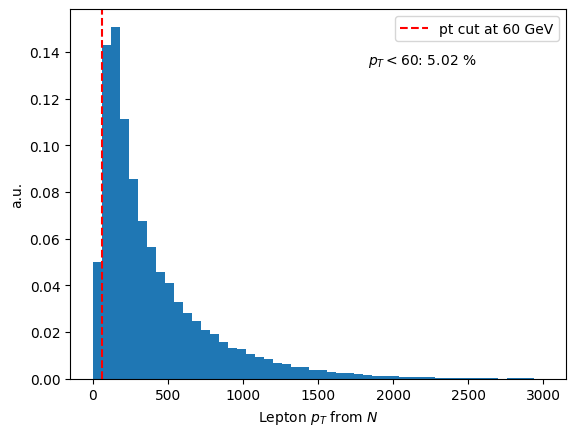

In [17]:
events = file3["Events"]
lhe_pt = events["LHEPart_pt"].array()

wr_np = lhe_pt[:, 2]
n_np  = lhe_pt[:, -1]

# numpy로 변환 (hist/weights 안정성)
wr_vals = ak.to_numpy(wr_np)
n_vals  = ak.to_numpy(n_np)

# 정규화 가중치 (a.u.)
w_wr = np.ones(len(wr_vals)) / len(wr_vals)
w_n  = np.ones(len(n_vals)) / len(n_vals)

# pt < 60 GeV 이벤트 비율 (%)
wr_lt60 = np.sum(wr_vals < 60) / len(wr_vals) * 100
n_lt60  = np.sum(n_vals < 60) / len(n_vals) * 100

plt.hist(wr_vals, bins=50, range=(0, 3000), weights=w_wr)
plt.xlabel("Lepton $p_{T}$ from $W_{R}$")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')
plt.text(0.60, 0.85, f"$p_{{T}} < 60$: {wr_lt60:.2f} %", transform=plt.gca().transAxes)
plt.legend()
plt.savefig("WR6000N5900_lepton_pt_from_WR.png")  # ✅ 그래프 저장
plt.show()

plt.hist(n_vals, bins=50, range=(0, 3000), weights=w_n)
plt.xlabel("Lepton $p_{T}$ from $N$")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')
plt.text(0.60, 0.85, f"$p_{{T}} < 60$: {n_lt60:.2f} %", transform=plt.gca().transAxes)
plt.legend()
plt.savefig("WR6000N5900_lepton_pt_from_N.png")  # ✅ 그래프 저장
plt.show()
